In [30]:
!pip install networkx
!pip install snfpy
!pip install missingno
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr, pearsonr, f_oneway
from statsmodels.stats.multitest import multipletests
from sklearn.neighbors import NearestNeighbors
import json
from sklearn.model_selection import GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score, roc_curve
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. ЗАГРУЗКА И БАЗОВАЯ ОЧИСТКА
# ==========================================
df = pd.read_csv('aorta_merged.csv', low_memory=False)
df.replace('', np.nan, inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='ignore')


key_components = [
    "Возраст, годы", "Пол", "Курение", "СДЛА", 
    "ФВ, %", "КДО ЛЖ, мл", "E, см/с", "E` средний"
]

# Создаем временную копию для безопасной сборки строкового ключа
# Принудительно приводим к string, заменяя NaN на метку 'NA', чтобы избежать склеивания пустых строк
df_key_temp = df[key_components].astype(str).fillna('NA')
df['synthetic_patient_key'] = df_key_temp.agg('_'.join, axis=1)

# Только после этого превращаем подходящие object-колонки в числа
for col in df.select_dtypes(include='object').columns:
    if col != 'synthetic_patient_key':  # Наш ключ должен остаться строкой
        df[col] = pd.to_numeric(df[col], errors='ignore')
# ==========================================
# 2. ОПРЕДЕЛЕНИЕ ПРИЗНАКОВ И ФИЛЬТР >70%
# ==========================================
features_dj = ['Возраст, годы', 'Пол', 'Рост, см', 'Вес, кг', 
               'Курение', 'Гипертоническая болезнь', 'Сахарный диабет']

features_ecg = ['HFNoise', 'RR', 'TpTe', 'VAT', 'QTc', 'QT/TQ', 'HFQRS', 'HFSNR', 
                'JA', 'J80A', 'TA', 'QRSenergy', 'Tenergy', 'Tpenergy', 'Sbeta', 'Beta', 
                'QRS11energy', 'QRS12energy', 'QRS2energy', 'QRSE1', 'QRSE2', 'QRSE3', 'QRSE4', 
                'TE1', 'TE2', 'TE3', 'TE4', 'QRSw', 'Pan', 'Pan.1', 'RA', 'SA', 
                'Pst', 'Pfi', 'QRSst', 'QRSfi', 'Tfi', 'PpeakP', 'PpeakN', 'Rpeak', 
                'Speak', 'Tpeak', 'Tons', 'Toffs', 'RonsF', 'RoffsF', 'SDNN']

all_features = features_dj + features_ecg
available_features = [f for f in all_features if f in df.columns]

# ✅ Фильтр: оставляем только те, где заполнено >70%
threshold = 0.70
valid_features = []
for col in available_features:
    fill_rate = df[col].notna().mean()
    if fill_rate >= threshold:
        valid_features.append(col)
    else:
        print(f"⚠️ Отброшен '{col}': заполнено {fill_rate:.1%} (<70%)")

print(f"✅ Осталось признаков для обучения: {len(valid_features)}")

num_cols = [c for c in valid_features if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = [c for c in valid_features if not pd.api.types.is_numeric_dtype(df[c])]

# ==========================================
# 3. ПРЕДОБРАБОТКА + МОДЕЛЬ
# ==========================================
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
], remainder='drop')

# 🔹 ПАЙПЛАЙН С ОТБОРОМ 10 ПРИЗНАКОВ И BRF
pipeline = Pipeline([
    ('prep', preprocessor),
    ('var_thresh', VarianceThreshold(threshold=0.0)),
    ('feature_selection', SelectFromModel(
        estimator=RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=-1),
        max_features=10,
        threshold=-np.inf
    )),
    ('brf', BalancedRandomForestClassifier(
        n_estimators=800,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        sampling_strategy='auto',
        replacement=False,
        random_state=42,
        n_jobs=-1,
        verbose=0
    ))
])

# ==========================================
# 4. ФУНКЦИЯ КЛИНИЧЕСКИХ МЕТРИК
# ==========================================
def calc_clinical_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    se = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    sp = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    acc = (tp + tn) / (tp + tn + fp + fn)
    auc_roc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    youden = se + sp - 1
    
    return {
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Se (Sens)': se, 'Sp (Spec)': sp, 'PPV': ppv, 'NPV': npv,
        'Accuracy': acc, 'AUC-ROC': auc_roc, 'PR-AUC': pr_auc, 'Youden': youden
    }

targets = [
    'Умеренный и тяжелый аортальный стеноз',
    'Умеренная и тяжелая аортальная недодстаточность',
    'Значимый порок аортального клапана'
]

results = {}
n_splits = 10

for target in targets:
    if target not in df.columns:
        print(f"⚠️ Цель '{target}' не найдена.")
        continue
        
    print(f"\n{'='*60}")
    print(f"🌳 BALANCED RANDOM FOREST | 10-FOLD GROUP CV: {target}")
    print(f"{'='*60}")
    
    y = df[target].copy()
    valid_idx = y.dropna().index
    X = df.loc[valid_idx, valid_features]
    y = y.loc[valid_idx]
    groups = df['synthetic_patient_key'].loc[valid_idx]
    
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []
    fold_thresholds = []
    fold_data = {'y_true': [], 'y_proba': [], 'fpr': [], 'tpr': []}
    
    # Создаем пустой список для сбора обученных моделей перед циклом по фолдам
    fold_pipelines = [] 
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        g_train, g_val = groups.iloc[train_idx], groups.iloc[val_idx]
        
        # 🔒 ПРОВЕРКА НА УТЕЧКУ (строго внутри фолда)
        leak = set(g_train.unique()).intersection(set(g_val.unique()))
        status = "⚠️ УТЕЧКА" if leak else "✅ OK"
        print(f"  Fold {fold:2d}: {status} | Train: {len(X_train)} | Val: {len(X_val)}")
        
        # 🔄 КЛОНИРОВАНИЕ ПАЙПЛАЙНА (чтобы состояния не переносились между фолдами)
        pipe_fold = clone(pipeline)
        
        # 🛠️ FIT ТОЛЬКО НА TRAIN (preprocessing + feature selection + model)
        pipe_fold.fit(X_train, y_train)
        
        # Сохраняем только что обученный пайплайн текущего фолда
        fold_pipelines.append(pipe_fold) 
        
        # 🔮 PREDICT ТОЛЬКО НА VAL
        y_proba_val = pipe_fold.predict_proba(X_val)[:, 1]
        
        # 📐 ПОИСК ОПТИМАЛЬНОГО ПОРОГА СТРОГО НА VALIDATION FOLD
        thresholds = np.linspace(0.01, 0.99, 99)
        best_t, best_score = 0.5, -1.0
        for t in thresholds:
            m = calc_clinical_metrics(y_val, y_proba_val, t)
            if m['Youden'] > best_score:
                best_score = m['Youden']
                best_t = t
        fold_thresholds.append(best_t)
        
        # 📊 МЕТРИКИ ПРИ ОПТИМАЛЬНОМ ПОРОГЕ
        m_opt = calc_clinical_metrics(y_val, y_proba_val, best_t)
        m_opt['Fold'] = fold
        fold_metrics.append(m_opt)
        
        # 📉 ДАННЫЕ ДЛЯ ПОСТРОЕНИЯ СРЕДНЕЙ ROC-КРИВОЙ
        fold_data['y_true'].append(y_val)
        fold_data['y_proba'].append(y_proba_val)
        fpr, tpr, _ = roc_curve(y_val, y_proba_val)
        fold_data['fpr'].append(fpr)
        fold_data['tpr'].append(tpr)

    # 📈 АГРЕГАЦИЯ РЕЗУЛЬТАТОВ
    df_folds = pd.DataFrame(fold_metrics)
    summary_metrics = df_folds.mean(numeric_only=True)
    std_metrics = df_folds.std(numeric_only=True)
    
    print(f"\n📊 Сводные метрики по {n_splits} фолдам (среднее ± std):")
    for k in ['AUC-ROC', 'PR-AUC', 'Se (Sens)', 'Sp (Spec)', 'PPV', 'NPV', 'Accuracy', 'Youden']:
        print(f"   {k:15s}: {summary_metrics[k]:.3f} ± {std_metrics[k]:.3f}")
    print(f"   Опт. порог (средний): {np.mean(fold_thresholds):.2f} ± {np.std(fold_thresholds):.2f}")
    
    # Записываем список моделей 'pipelines' внутрь результатов таргета
    results[target] = {
        'fold_metrics': df_folds,
        'summary': summary_metrics,
        'std': std_metrics,
        'optimal_threshold_mean': np.mean(fold_thresholds),
        'fold_data': fold_data,
        'pipelines': fold_pipelines  
    }
    
    # 🖼️ ВИЗУАЛИЗАЦИЯ: СРЕДНЯЯ ROC-КРИВАЯ + МАТРИЦА
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Mean ROC Curve
    mean_tpr = np.linspace(0, 1, 100)
    all_tprs = []
    aucs = []
    for i in range(n_splits):
        fpr, tpr = fold_data['fpr'][i], fold_data['tpr'][i]
        aucs.append(roc_auc_score(fold_data['y_true'][i], fold_data['y_proba'][i]))
        tpr_interp = np.interp(mean_tpr, fpr, tpr)
        tpr_interp[0] = 0.0
        all_tprs.append(tpr_interp)
    mean_tpr_acc = np.mean(all_tprs, axis=0)
    mean_tpr_acc[-1] = 1.0
    mean_auc = np.mean(aucs)
    
    axes[0].plot(mean_tpr, mean_tpr_acc, label=f'Mean ROC (AUC = {mean_auc:.3f})', linewidth=2, color='b')
    axes[0].plot([0, 1], [0, 1], 'k--', label='Chance')
    axes[0].set_xlabel('1 - Specificity')
    axes[0].set_ylabel('Sensitivity')
    axes[0].set_title(f'Mean ROC Curve (10-Fold Group CV) — {target}')
    axes[0].legend(loc='lower right')
    axes[0].grid(alpha=0.3)
    
    # Aggregated Confusion Matrix
    total_tp = int(df_folds['TP'].sum())
    total_fp = int(df_folds['FP'].sum())
    total_fn = int(df_folds['FN'].sum())
    total_tn = int(df_folds['TN'].sum())
    cm_agg = np.array([[total_tn, total_fp], [total_fn, total_tp]])
    
    sns.heatmap(cm_agg, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                xticklabels=['Neg (0)', 'Pos (1)'], yticklabels=['Neg (0)', 'Pos (1)'])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    axes[1].set_title(f'Aggregated Confusion Matrix\n(All {n_splits} Folds)')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. СВОДНАЯ ТАБЛИЦА И СОХРАНЕНИЕ
# ==========================================
print("\n" + "="*70)
print("📋 СВОДНАЯ ТАБЛИЦА (Balanced Random Forest | 10-Fold Group CV)")
print("="*70)

summary_rows = []
for target, data in results.items():
    row = {'Цель': target, 'Опт. порог (mean)': data['optimal_threshold_mean']}
    row.update(data['summary'])
    # Добавляем std для ключевых метрик
    row.update({f'{k} (std)': data['std'][k] for k in ['AUC-ROC', 'Se (Sens)', 'Sp (Spec)', 'PPV', 'NPV']})
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
cols_order = ['Цель', 'Опт. порог (mean)', 
              'AUC-ROC', 'AUC-ROC (std)', 'PR-AUC', 
              'Se (Sens)', 'Se (Sens) (std)', 'Sp (Spec)', 'Sp (Spec) (std)', 
              'PPV', 'PPV (std)', 'NPV', 'NPV (std)', 'Accuracy', 'Youden']
summary_df = summary_df[[c for c in cols_order if c in summary_df.columns]]

pd.set_option('display.float_format', lambda x: f'{x:.3f}')
print(summary_df.to_string(index=False))

summary_df.to_csv('brf_clinical_metrics_10fold_cv.csv', index=False, sep=';', encoding='utf-8-sig')
print(f"\n✅ Сохранено в 'brf_clinical_metrics_10fold_cv.csv'")

⚠️ Отброшен 'Рост, см': заполнено 69.8% (<70%)
⚠️ Отброшен 'Вес, кг': заполнено 69.9% (<70%)
✅ Осталось признаков для обучения: 52

🌳 BALANCED RANDOM FOREST | 10-FOLD GROUP CV: Умеренный и тяжелый аортальный стеноз
  Fold  1: ✅ OK | Train: 2252 | Val: 251


KeyboardInterrupt: 

📊 ВАЖНОСТЬ ПРИЗНАКОВ (Усредненная по 10 фолдам Кросс-Валидации)

🎯 Цель: Умеренный и тяжелый аортальный стеноз
────────────────────────────────────────────────────────────
           Признак  Важность (Gini)  % от суммы
num__Возраст, годы           0.2103       21.03
         num__J80A           0.1065       10.65
           num__TA           0.0975        9.75
         num__SDNN           0.0930        9.30
           num__JA           0.0893        8.93
    num__QRSenergy           0.0865        8.65
        num__Sbeta           0.0833        8.33
        num__QRSE2           0.0795        7.95
           num__RR           0.0791        7.91
        num__QRSE4           0.0750        7.50


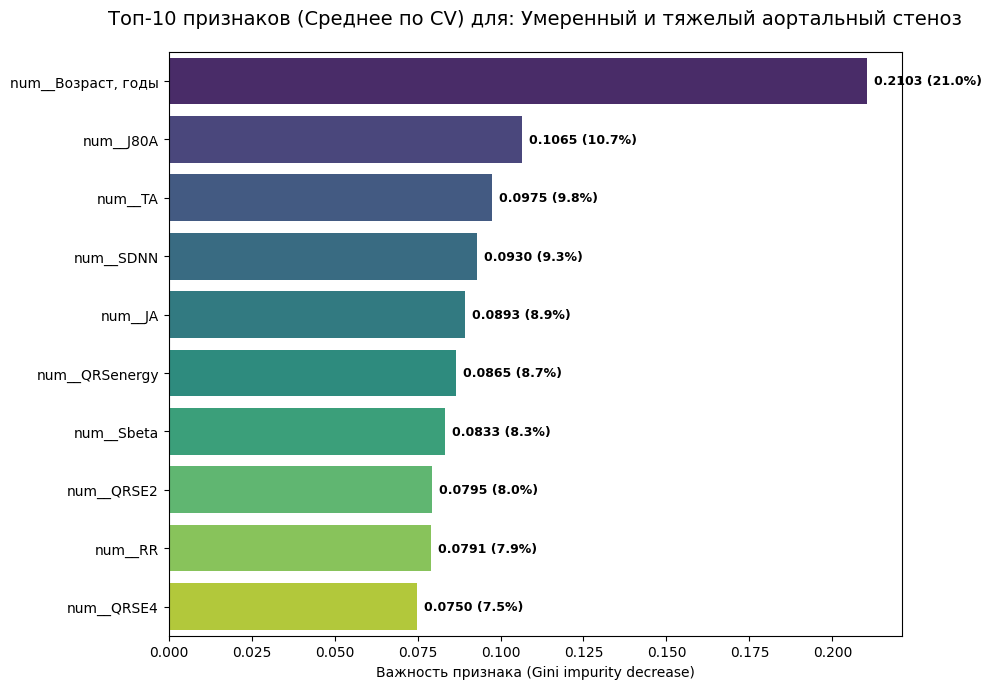


🎯 Цель: Умеренная и тяжелая аортальная недодстаточность
────────────────────────────────────────────────────────────
           Признак  Важность (Gini)  % от суммы
num__Возраст, годы           0.2666       26.66
         num__SDNN           0.0911        9.11
          num__QTc           0.0841        8.41
        num__QRSE1           0.0835        8.35
        num__Sbeta           0.0832        8.32
        num__QRSE4           0.0812        8.12
           num__SA           0.0799        7.99
           num__RA           0.0792        7.92
        num__Speak           0.0763        7.63
      num__HFNoise           0.0749        7.49


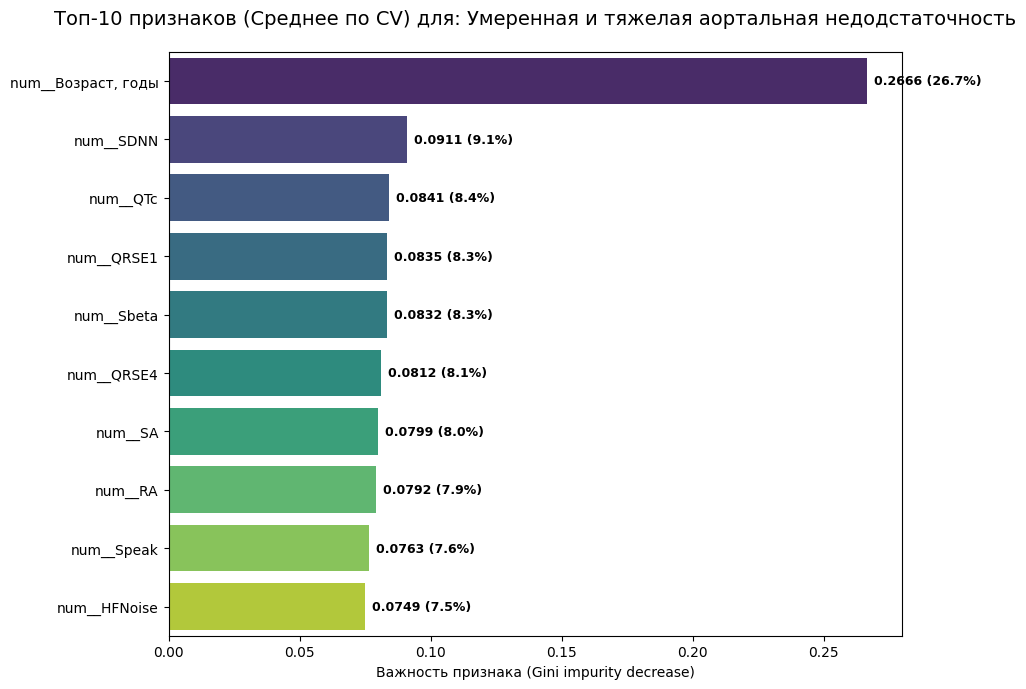


🎯 Цель: Значимый порок аортального клапана
────────────────────────────────────────────────────────────
           Признак  Важность (Gini)  % от суммы
num__Возраст, годы           0.2629       26.29
         num__SDNN           0.0907        9.07
           num__JA           0.0865        8.65
        num__QRSE1           0.0850        8.50
        num__Sbeta           0.0829        8.29
          num__QTc           0.0811        8.11
           num__SA           0.0808        8.08
           num__RR           0.0803        8.03
         num__Beta           0.0786        7.86
      num__HFNoise           0.0713        7.13


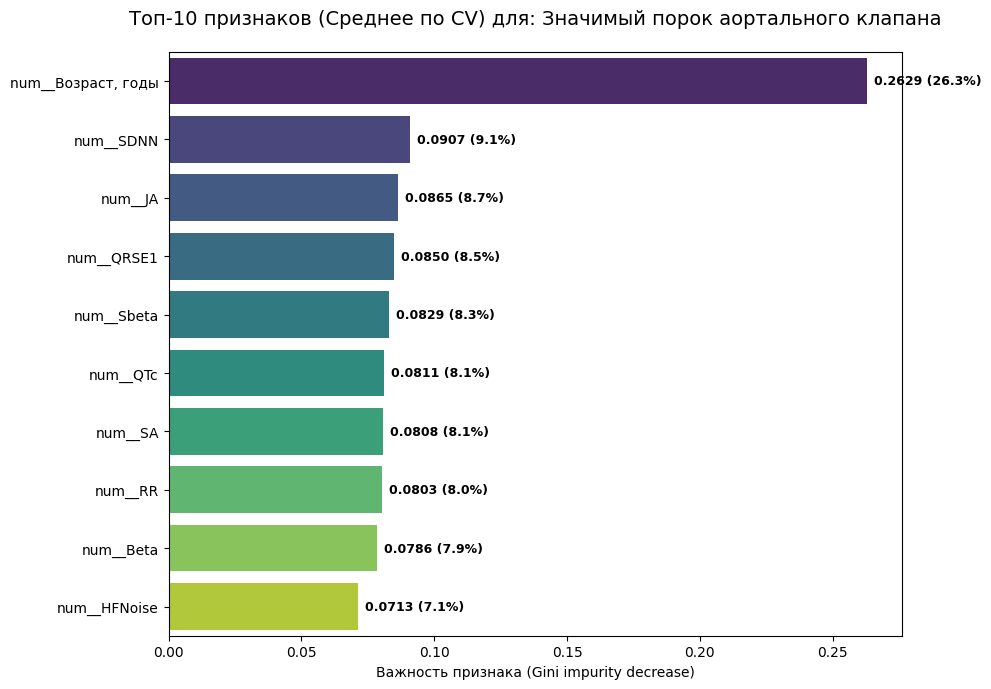


✅ Усредненные файлы с важностью успешно сохранены.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("📊 ВАЖНОСТЬ ПРИЗНАКОВ (Усредненная по 10 фолдам Кросс-Валидации)")
print("="*60)

for target, data in results.items():
    # 🛑 ИСПРАВЛЕНО: Проверяем, что список пайплайнов существует в сохраненных данных
    if 'pipelines' not in data or not data['pipelines']:
        print(f"⚠️ Нет сохраненных моделей для цели: {target}")
        continue
        
    pipelines_list = data['pipelines']
    all_importances = []
    final_names = None
    
    # 🔄 ИСПРАВЛЕНО: Проходим циклом по всем 10 обученным пайплайнам из фолдов
    for pipe in pipelines_list:
        # 1. Получаем имена признаков ПОСЛЕ предобработки (One-Hot и т.д.)
        names_after_prep = pipe.named_steps['prep'].get_feature_names_out(valid_features)
        
        # 2. Фильтруем имена по маске VarianceThreshold (убирает константы)
        mask_vt = pipe.named_steps['var_thresh'].get_support()
        names_after_vt = names_after_prep[mask_vt]
        
        # 3. Фильтруем имена по маске SelectFromModel (оставляет топ-10)
        mask_fs = pipe.named_steps['feature_selection'].get_support()
        fold_names = names_after_vt[mask_fs]
        
        # Запоминаем имена признаков (берём из первого фолда для стабильности отображения)
        if final_names is None:
            final_names = fold_names
            
        # 4. Извлекаем важность из BalancedRandomForest для текущего фолда
        all_importances.append(pipe.named_steps['brf'].feature_importances_)
    
    # 📐 ИСПРАВЛЕНО: Считаем среднюю важность каждого признака по всем 10 фолдам
    mean_importances = np.mean(all_importances, axis=0)
    
    # 5. Собираем итоговую таблицу
    df_imp = pd.DataFrame({
        'Признак': final_names,
        'Важность (Gini)': mean_importances
    }).sort_values('Важность (Gini)', ascending=False).reset_index(drop=True)
    
    # 6. Добавляем проценты вклада
    df_imp['% от суммы'] = (df_imp['Важность (Gini)'] / df_imp['Важность (Gini)'].sum() * 100).round(2)
    
    print(f"\n🎯 Цель: {target}")
    print(f"{'─'*60}")
    print(df_imp.to_string(index=False, float_format=lambda x: f"{x:.4f}" if x < 1 else f"{x:.2f}"))
    
    # 7. Визуализация
    plt.figure(figsize=(10, 7))
    bars = sns.barplot(x='Важность (Gini)', y='Признак', data=df_imp, 
                       palette='viridis', orient='h')
    plt.xlabel('Важность признака (Gini impurity decrease)')
    plt.ylabel('')
    plt.title(f'Топ-10 признаков (Среднее по CV) для: {target}', fontsize=14, pad=20)
    
    # Подписываем значения на барах
    max_val = max(df_imp['Важность (Gini)'])
    for p, val, pct in zip(bars.patches, df_imp['Важность (Gini)'], df_imp['% от суммы']):
        plt.text(p.get_width() + (max_val * 0.01), p.get_y() + p.get_height()/2, 
                 f'{val:.4f} ({pct:.1f}%)', va='center', fontsize=9, fontweight='bold')
        
    plt.tight_layout()
    plt.show()
    
    # Сохранение в CSV
    safe_target_name = target.replace(" ", "_").replace("/", "_").replace(",", "")
    df_imp.to_csv(f'feature_importance_{safe_target_name}.csv', 
                  index=False, sep=';', encoding='utf-8-sig')

print("\n✅ Усредненные файлы с важностью успешно сохранены.")